# Library

In [19]:
import sys
sys.path.append("/project/assistant")

%load_ext autoreload
%autoreload 2

import json
import os

# huggingface downloads: quiet text logs, no widget progress bars
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"
import time
from pathlib import Path

import pandas as pd
from tqdm import tqdm
from elasticsearch import Elasticsearch
from openai import OpenAI

from embeddings import SentenceTransformerEmbeddings
from metrics import CallMetrics
from judge import AnswerEvaluation, LLMJudge
from rag import ObsidianRAG
from search import VaultSearcher, ElasticsearchRetriever
import numpy as np 
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# RAG

In [20]:
model_name = os.getenv("EMBED_MODEL", "all-MiniLM-L6-v2")
query_prefix = ("Represent this sentence for searching relevant passages: "
                if "bge" in model_name else "")

es = Elasticsearch(os.getenv("ELASTIC_HOST", "http://elasticsearch:9200"))
embeddings = SentenceTransformerEmbeddings(model_name, query_prefix)
searcher = VaultSearcher(es, embeddings, os.getenv("ES_INDEX", "obsidian_notes"))
retriever = ElasticsearchRetriever(search_fn=searcher.hybrid, num_results=10)

# both providers on purpose: the whole point here is comparing them
gpt = OpenAI()
ollama = OpenAI(base_url="http://ollama:11434/v1", api_key="ollama")

rag_gpt = ObsidianRAG(retriever, gpt, model="gpt-5.4-mini")
rag_local = ObsidianRAG(retriever, ollama, model="qwen2.5:7b-instruct")

In [21]:
out = rag_gpt.invoke("What is the agentic loop?")
print(out["answer"])
print("---")
print("sources:", len(out["source_documents"]), "| tokens:", out["usage"].total_tokens)

The agentic loop is a repeated cycle where the model decides whether to call tools, your code runs those tools, appends the results to the message history, and then sends everything back to the model until it returns a final answer with no more tool calls.

Sources:
- llm-zoomcamp-2026/01-agentic-rag/14-agentic-loop.md
---
sources: 10 | tokens: 4902


# LLM as Judge

Free text has no ground truth: there is no expected path to compare an
answer against. The course's answer to this is llm-as-judge: a strong
model reads the question and the generated answer and classifies the
relevance as RELEVANT, PARTLY_RELEVANT or NON_RELEVANT, with its
reasoning written before the verdict. The judge runs at temperature
zero and answers through the api's structured output, so the shape is
guaranteed and a verdict outside the vocabulary cannot happen.

One structural note against the course's offline setup: this vault has
no gold answers (the ground truth maps questions to notes, not to
reference answers), so the offline run below uses the reference-free
judge, the same one production would use, applied over a fixed sample.

The judge is validated by hand first: a few verdicts are read next to
the answers they judge, because a judge nobody audited is just another
opinion.

In [22]:
# the judge lives in the package (assistant/judge.py): prompt,
# structured verdict and temperature zero all inside LLMJudge.
# The cells below call judge() as a function, so the method is
# bound to the old name, same bridge as the searcher aliases.
judge_llm = LLMJudge(gpt, model="gpt-5.4-mini")
judge = judge_llm.judge

In [23]:
# manual audit: three answers and their verdicts, read side by side
seed = pd.read_json("/project/data/claude_ground_truth.json")

for q in seed.sample(3, random_state=7).itertuples():
    out = rag_gpt.invoke(q.question)
    verdict = judge(q.question, out["answer"])
    print("Q:", q.question)
    print("A:", out["answer"][:250])
    print("VERDICT:", verdict.relevance)
    print("REASONING:", verdict.reasoning)
    print("=" * 70)

Q: why do we describe our function in a data format instead of showing the model the python code
A: We describe the function in a data format because the model does not see our Python code; it only sees a schema describing what the function does and what arguments it takes. The notes also say LLMs are language agnostic, so JSON works across Python,
VERDICT: RELEVANT
REASONING: The generated answer directly addresses the question by explaining why a function is described in a data format rather than exposing Python code. It states that the model only sees a schema of the function and its arguments, and that using a language-agnostic format like JSON makes it work across different programming languages. This matches the likely intent of the source material about function calling and is clearly on-topic and responsive.
Q: how do i make sure my stored records survive when the container gets stopped and started again
A: Use a named Docker volume for Postgres data persistence. The notes show

The generation benchmark compares both models on exactly the same 50 questions, sampled from the evaluation set with a fixed random seed. Each question is answered once by `gpt-5.4-mini` through the API and once by `qwen2.5:7b-instruct` through the local Ollama runtime, and every answer is then evaluated by the same judge, here using the `gpt-5.4-mini` model as judge.

The benchmark also records response time and estimated generation cost for each call. Because a full run takes roughly an hour, due to the local model, and incurs a small API cost, the results are cached after the first execution in `data/generation_eval.csv`.

If the cache exists, the notebook loads it directly. To reproduce the benchmark from scratch, delete the CSV and rerun the cell.


In [24]:
RESULTS_PATH = Path("/project/data/generation_eval.csv")

if RESULTS_PATH.exists():
    results = pd.read_csv(RESULTS_PATH)
    print(f"loaded cached results: {len(results)} rows")
else:
    sample = seed.sample(50, random_state=42)
    rows = []
    for name, rag in [("gpt-5.4-mini", rag_gpt),
                      ("qwen2.5:7b-instruct", rag_local)]:
        for q in tqdm(sample.itertuples(), total=len(sample), desc=name):
            started = time.time()
            out = rag.invoke(q.question)
            elapsed = time.time() - started
            call = CallMetrics.from_call(name, out["usage"], elapsed)
            verdict = judge(q.question, out["answer"])
            rows.append({
                "model": name,
                "question": q.question,
                "difficulty": q.difficulty,
                "relevance": verdict.relevance,
                "explanation": verdict.reasoning,
                "response_time": call.response_time,
                "cost": call.cost,
            })
    results = pd.DataFrame(rows)
    results.to_csv(RESULTS_PATH, index=False)
    print(f"saved {len(results)} rows to {RESULTS_PATH}")

loaded cached results: 100 rows


In [25]:
display(results.head(10))

,model,question,difficulty,relevance,explanation,response_time,cost
0,gpt-5.4-mini,why does the looping setup end up costing more...,hard,RELEVANT,The generated answer directly addresses the qu...,2.254054,0.001553
1,gpt-5.4-mini,when is plain rag good enough that I dont need...,easy,RELEVANT,The generated answer directly addresses the qu...,1.288563,0.001360
2,gpt-5.4-mini,what is the difference between hit rate and mrr,easy,RELEVANT,The generated answer directly addresses the qu...,1.396609,0.001577
3,gpt-5.4-mini,why rerun all the tests every time i tweak the...,hard,RELEVANT,The generated answer directly addresses the qu...,1.889551,0.001512
4,gpt-5.4-mini,why does most of the testing effort go into th...,hard,RELEVANT,The generated answer directly addresses the qu...,1.542061,0.001474
5,gpt-5.4-mini,could the same trick help me switch to a diffe...,hard,RELEVANT,The question asks whether the same trick could...,1.084791,0.001425
6,gpt-5.4-mini,is there a shortcut to grab the reply text wit...,hard,RELEVANT,The generated answer directly addresses the us...,0.863582,0.001432
7,gpt-5.4-mini,why keep what the person actually typed separa...,hard,RELEVANT,The generated answer directly addresses the qu...,1.247879,0.001514
8,gpt-5.4-mini,when the table gets big is there a cheaper way...,hard,NON_RELEVANT,The question asks about a cheaper way to sort ...,1.990237,0.001575
9,gpt-5.4-mini,how do I add the thumbs up and down counts to ...,easy,RELEVANT,The answer is directly about adding thumbs up ...,1.718490,0.001682


In [26]:
summary = results.groupby("model").agg(
    relevant=("relevance", lambda s: (s == "RELEVANT").mean()),
    partly=("relevance", lambda s: (s == "PARTLY_RELEVANT").mean()),
    non_relevant=("relevance", lambda s: (s == "NON_RELEVANT").mean()),
    avg_seconds=("response_time", "mean"),
    avg_cost=("cost", "mean"),
).round(3)
summary

,relevant,partly,non_relevant,avg_seconds,avg_cost
model,,,,,
gpt-5.4-mini,0.76,0.06,0.18,1.355,0.001
qwen2.5:7b-instruct,0.60,0.32,0.08,70.480,0.000


In [27]:
# # the failures, for the qualitative read: what does each model get wrong?
# results[results.relevance != "RELEVANT"][
#     ["model", "difficulty", "question", "relevance", "explanation"]
# ].sort_values("model")

The verdict composition per model. Blue is the share judged RELEVANT,
gray the partial answers, orange the failures. The two models fail in
different ways: gpt refuses honestly when the context has no answer,
qwen wanders around loosely related content instead.


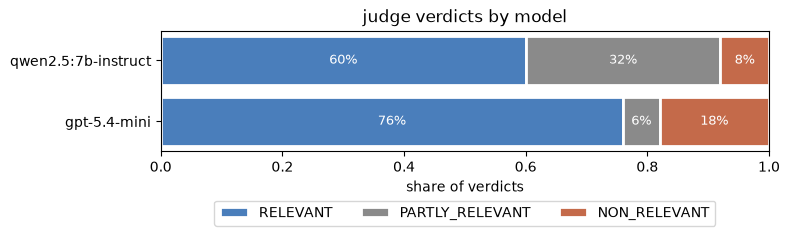

In [28]:
order = ["RELEVANT", "PARTLY_RELEVANT", "NON_RELEVANT"]
colors = {"RELEVANT": "#4a7ebb", "PARTLY_RELEVANT": "#8a8a8a",
          "NON_RELEVANT": "#c46a4a"}

share = (results.groupby("model")["relevance"].value_counts(normalize=True)
         .unstack().reindex(columns=order).fillna(0))

fig, ax = plt.subplots(figsize=(8, 2.8))
left = np.zeros(len(share))
for verdict in order:
    vals = share[verdict].values
    ax.barh(share.index, vals, left=left, color=colors[verdict],
            label=verdict, edgecolor="white", linewidth=2)
    for y, (start, v) in enumerate(zip(left, vals)):
        if v > 0.04:
            ax.text(start + v / 2, y, f"{v:.0%}", ha="center",
                    va="center", color="white", fontsize=9)
    left += vals
ax.set_xlim(0, 1)
ax.set_xlabel("share of verdicts")
ax.set_title("judge verdicts by model")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.35))
plt.tight_layout()
plt.show()


Answer quality split by question difficulty. Both models answer nearly
every easy question well; every single failure lives in the hard set.
Generation quality is bounded by retrieval quality: when the right
note reaches the context, both models answer, and when it does not,
neither can.

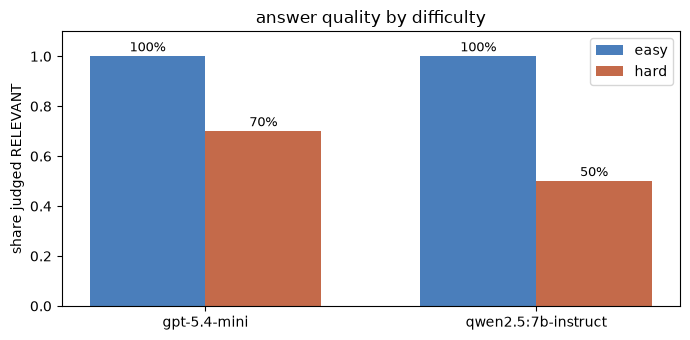

In [29]:
rel_rate = (results.assign(ok=results.relevance == "RELEVANT")
            .groupby(["model", "difficulty"])["ok"].mean().unstack())

fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(rel_rate.index))
w = 0.35
ax.bar(x - w/2, rel_rate["easy"], w, label="easy", color="#4a7ebb")
ax.bar(x + w/2, rel_rate["hard"], w, label="hard", color="#c46a4a")
for i, v in enumerate(rel_rate["easy"]):
    ax.text(i - w/2, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)
for i, v in enumerate(rel_rate["hard"]):
    ax.text(i + w/2, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)
ax.set_xticks(x, rel_rate.index)
ax.set_ylabel("share judged RELEVANT")
ax.set_title("answer quality by difficulty")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()


The price of each mode: seconds of waiting per answer, and dollars per
answer. The local model is free and private, and fifty times slower on
this cpu; the api model costs about a tenth of a cent per question.


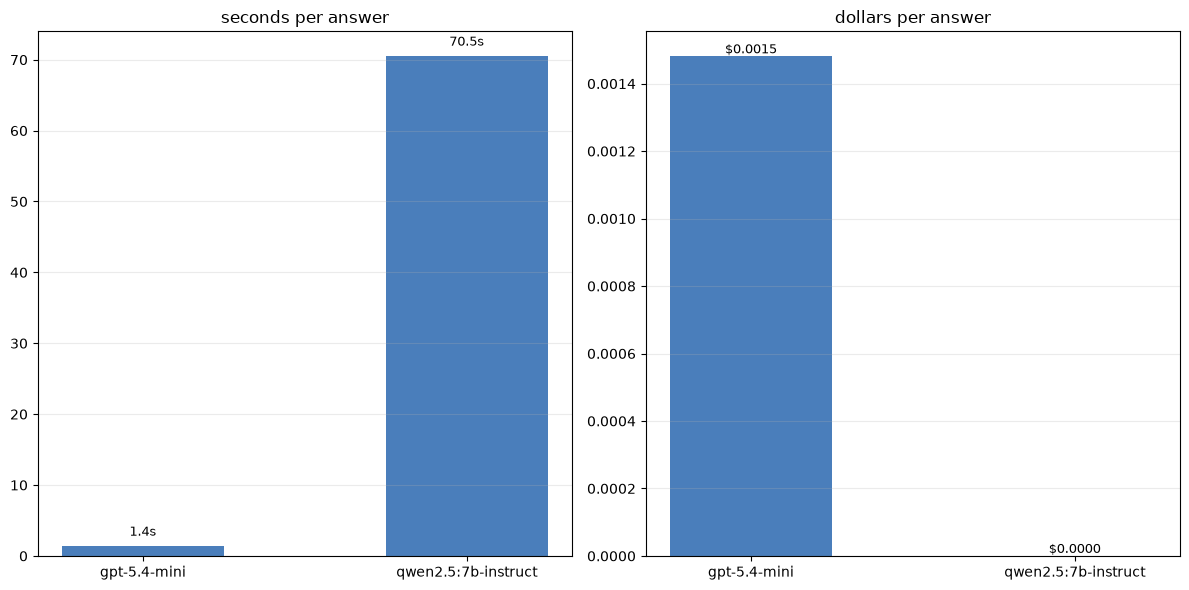

In [30]:
agg = results.groupby("model").agg(seconds=("response_time", "mean"),
                                   cost=("cost", "mean"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.bar(agg.index, agg.seconds, color="#4a7ebb", width=0.5)
for i, v in enumerate(agg.seconds):
    ax1.text(i, v + 1.5, f"{v:.1f}s", ha="center", fontsize=9)
ax1.set_title("seconds per answer")
ax1.grid(alpha=0.25, axis="y")

ax2.bar(agg.index, agg.cost, color="#4a7ebb", width=0.5)
for i, v in enumerate(agg.cost):
    ax2.text(i, v, f"${v:.4f}", ha="center", va="bottom", fontsize=9)
ax2.set_title("dollars per answer")
ax2.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


How good could a perfect generator be on this sample? Its upper bound is set by retrieval quality: even a generator that answers perfectly whenever the correct note is present cannot recover information that never reaches its context.

Using the retrieval hit rates measured in the retrieval notebook, 0.98 for easy questions and 0.68 for hard ones, and the difficulty mix of this sample, the expected ceiling is about 76% `RELEVANT`, shown by the dashed line below.

`gpt-5.4-mini` reaches essentially this ceiling, indicating that its generation stage introduces little to no additional loss: most failures come from retrieval misses. The gap between the local model and this upper bound therefore isolates its generation loss, largely independent of retrieval.


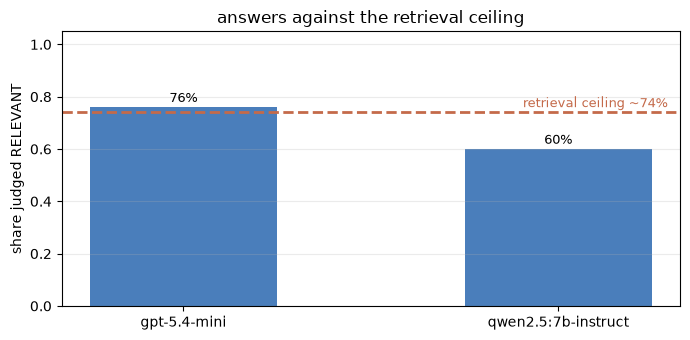

In [31]:
# the ceiling: share of questions whose note reaches the context, from
# the retrieval hit rates measured in 02 (0.98 easy, 0.68 hard) and
# this sample's difficulty mix
mix = results[results.model == "gpt-5.4-mini"]["difficulty"].value_counts(normalize=True)
ceiling = mix.get("easy", 0) * 0.98 + mix.get("hard", 0) * 0.68

rel = (results.assign(ok=results.relevance == "RELEVANT")
       .groupby("model")["ok"].mean())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(rel.index, rel.values, color="#4a7ebb", width=0.5)
for i, v in enumerate(rel.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=9)

ax.axhline(ceiling, color="#c46a4a", linestyle="--", linewidth=2)
ax.text(0.98, ceiling + 0.02, f"retrieval ceiling ~{ceiling:.0%}",
        ha="right", color="#c46a4a", fontsize=9,
        transform=ax.get_yaxis_transform())

ax.set_ylabel("share judged RELEVANT")
ax.set_title("answers against the retrieval ceiling")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


The same cross-check, drawn: for each model, the verdict composition
when the expected note was found against when it was missed. Good
answers live almost entirely where retrieval delivered the note.


100%|██████████| 50/50 [00:02<00:00, 16.95it/s]


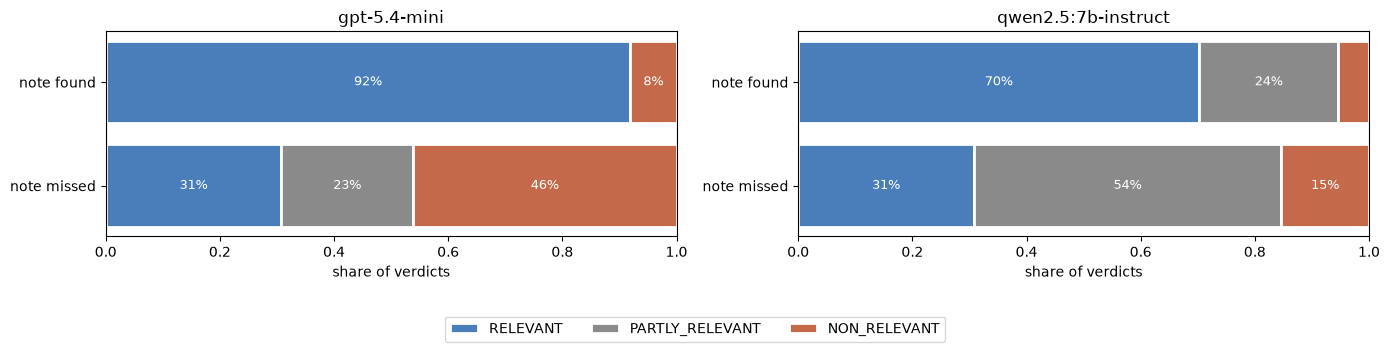

In [32]:
# the same evaluated sample, with the retrieval outcome per question
sample = seed.sample(50, random_state=42)
hits = [q.path in [r["path"] for r in searcher.hybrid(q.question, num_results=10)]
        for q in tqdm(sample.itertuples(), total=len(sample))]
sample = sample.assign(hit=hits)

merged = results.merge(sample[["question", "hit"]], on="question")

order = ["RELEVANT", "PARTLY_RELEVANT", "NON_RELEVANT"]
colors = {"RELEVANT": "#4a7ebb", "PARTLY_RELEVANT": "#8a8a8a",
          "NON_RELEVANT": "#c46a4a"}
labels = {True: "note found", False: "note missed"}

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)
for ax, model in zip(axes, merged.model.unique()):
    part = merged[merged.model == model]
    share = (part.groupby("hit")["relevance"].value_counts(normalize=True)
             .unstack().reindex(columns=order).fillna(0))
    ys = [labels[h] for h in share.index]
    left = np.zeros(len(share))
    for verdict in order:
        vals = share[verdict].values
        ax.barh(ys, vals, left=left, color=colors[verdict],
                edgecolor="white", linewidth=2, label=verdict)
        for y, (s, v) in enumerate(zip(left, vals)):
            if v > 0.06:
                ax.text(s + v / 2, y, f"{v:.0%}", ha="center",
                        va="center", color="white", fontsize=9)
        left += vals
    ax.set_title(model)
    ax.set_xlim(0, 1)
    ax.set_xlabel("share of verdicts")

handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles[:3], lbls[:3], ncol=3, loc="lower center",
           bbox_to_anchor=(0.5, -0.18))
plt.tight_layout()
plt.show()


Reading the chart by retrieval outcome makes the source of each model's errors clear. When the expected note is found, `gpt-5.4-mini` turns 92% of those contexts into `RELEVANT` answers, behaving close to the retrieval-limited ceiling discussed above. `qwen2.5:7b-instruct` reaches only 70%, with another 24% judged `PARTLY_RELEVANT`. That gap is generation loss: the necessary evidence was available, but the model did not use it as effectively.

When the expected note is missed, the two models fail differently. `gpt-5.4-mini` more often produces clearly unsupported answers, with 46% judged `NON_RELEVANT`, while Qwen tends to stay near the topic without fully answering it, producing 54% `PARTLY_RELEVANT`.

One result is shared by both models: about 31% of answers remain `RELEVANT` even when the expected note is absent from the retrieved set. In those cases, another retrieved note contained enough overlapping information to answer correctly. This shows that the single-note ground truth is slightly conservative: a retrieval miss does not always imply a true context miss.

# Validating the judge

The production judge works without a reference, because the vault has no gold answers. But the ground truth knows which NOTE should answer each question, and that note's content can serve as reference for a better-informed judge. Re-judging the same answers with it measures how much the cheap judge can be trusted: strong agreement on the diagonal validates the reference-free strategy the app uses. Answers are regenerated for the same 50 questions, which is safe because the whole chain runs at temperature zero: same questions, same retrieval, same answers as the judged run.


In [15]:
import seaborn as sns

REF_JUDGE_PROMPT = """
You are an expert evaluator for a RAG system.
You will judge whether the generated answer is relevant and consistent
with the reference material, which is the note that should answer this
question. Classify as "NON_RELEVANT", "PARTLY_RELEVANT" or "RELEVANT",
and explain your reasoning before deciding.

Question: {question}

Reference material:
{reference}

Generated Answer: {answer}
""".strip()


def judge_with_reference(question, answer, reference):
    response = gpt.chat.completions.parse(
        model="gpt-5.4-mini",
        temperature=0,
        messages=[{"role": "user", "content": REF_JUDGE_PROMPT.format(
            question=question, answer=answer, reference=reference[:6000])}],
        response_format=AnswerEvaluation,
    )
    return response.choices[0].message.parsed


cached = pd.read_csv("/project/data/generation_eval.csv")
without_ref = cached[cached.model == "gpt-5.4-mini"].set_index("question")["relevance"]

sample = seed.sample(50, random_state=42)
rows = []
for q in tqdm(sample.itertuples(), total=len(sample)):
    out = rag_gpt.invoke(q.question)
    reference = (Path("/project/demo_vault") / q.path).read_text()
    verdict = judge_with_reference(q.question, out["answer"], reference)
    rows.append({"question": q.question,
                 "with_ref": verdict.relevance,
                 "without_ref": without_ref.get(q.question)})

df_compare = pd.DataFrame(rows)
print(f"agreement: {(df_compare.with_ref == df_compare.without_ref).mean():.0%}")


100%|██████████| 50/50 [02:56<00:00,  3.52s/it]

agreement: 72%


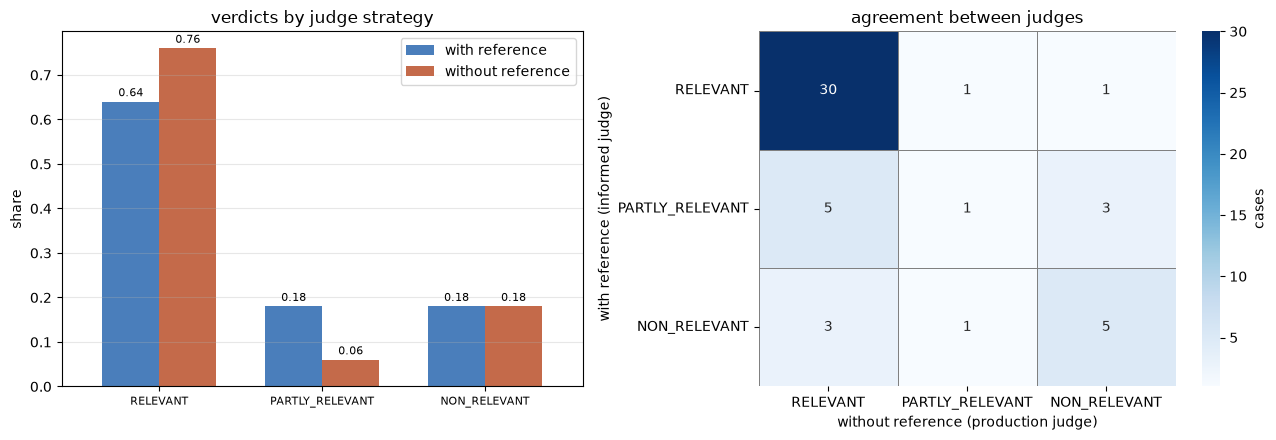

In [16]:
order = ["RELEVANT", "PARTLY_RELEVANT", "NON_RELEVANT"]
comparison = pd.DataFrame({
    "with reference": df_compare["with_ref"].value_counts(normalize=True),
    "without reference": df_compare["without_ref"].value_counts(normalize=True),
}).reindex(order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

comparison.plot(kind="bar", ax=axes[0], color=["#4a7ebb", "#c46a4a"], width=0.7)
axes[0].set_title("verdicts by judge strategy")
axes[0].set_ylabel("share")
axes[0].set_xticklabels(comparison.index, rotation=0, fontsize=8)
axes[0].grid(axis="y", alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=2, fontsize=8)

crosstab = (pd.crosstab(df_compare["with_ref"], df_compare["without_ref"])
            .reindex(index=order, columns=order, fill_value=0))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            linewidths=0.5, linecolor="gray", cbar_kws={"label": "cases"})
axes[1].set_title("agreement between judges")
axes[1].set_xlabel("without reference (production judge)")
axes[1].set_ylabel("with reference (informed judge)")

plt.tight_layout()
plt.show()


The production judge agrees with the reference-informed judge in 72% of cases, rising to 80% when `PARTLY_RELEVANT` and `NON_RELEVANT` are collapsed into a single non-relevant class.

The disagreement is asymmetric. The blind production judge is more permissive: in 8 of the 50 cases, it marks an answer `RELEVANT` that the informed judge downgrades. The reference-informed judge is stricter, but introduces a limitation of its own: it evaluates against one expected note, so an answer supported by a different retrieved note containing the same information may be penalized despite being correct.

The two judges therefore provide complementary views rather than a single unquestionable ground truth. The production judge estimates whether the answer is useful on its own; the informed judge measures agreement with the expected source. The true relevance rate likely lies between the two. For model comparison, the production judge remains appropriate because every model is evaluated under the same criterion.


# Conclusion

`gpt-5.4-mini` performs better on every measured axis except price: 76% of its answers are judged `RELEVANT`, compared with 60% for the local Qwen model, while average response time drops from about 70 seconds to 1.4 seconds. The API cost is roughly a tenth of a cent per question. The local model remains available as the free and private alternative, with its quality and latency trade-offs now quantified.

The ceiling analysis explains most of this gap. Given the measured retrieval hit rates and the difficulty distribution of this sample, a perfect generator would be expected to reach about 76% `RELEVANT`. `gpt-5.4-mini` lands almost exactly at that level, indicating that its aggregate performance is largely limited by retrieval rather than generation. Qwen remains about 16 percentage points below the same ceiling, revealing a substantial generation loss even when useful context is available.

The per-question analysis adds an important nuance. Some retrieval hits still produce poor answers, showing that GPT is not literally lossless at generation time. Conversely, some retrieval misses still produce good answers because another retrieved note contains equivalent information. These effects approximately cancel in aggregate, which is why GPT ends up so close to the theoretical ceiling.

The practical implication is clear: the main bottleneck of the current system is no longer the generator. Further gains are more likely to come from improving retrieval on the hard subset than from replacing `gpt-5.4-mini` with a stronger generation model.
